# Assignment 2: Sensitivity of the No-Trade Bandwidth to Transaction Costs

**Objective:** This notebook extends the Hodges-Neuberger (1989) binomial framework to analyze the sensitivity of the optimal hedging strategy to varying levels of proportional transaction costs $k$. By iterating across a spectrum of friction levels $k \in \{0.002, 0.05\}$, we empirically map the expansion of the no-trade zone and demonstrate how transaction costs force a deviation from the frictionless Black-Scholes replication strategy.

**Theoretical Setup:**
As established in Assignment 1, the optimal trading strategy at $t=0$ for a short position in a European call option is characterized by a "no-trade" bandwidth $[x^-, x^+]$. Within this region, the transaction costs incurred by rebalancing outweigh the expected utility gains from risk reduction.

In this sensitivity analysis, we perform the following:
1. **Parameter Sweep:** Iterate through the transaction cost vector $k \in \{0.002, 0.005, 0.01, 0.015, 0.02, 0.03, 0.04, 0.05\}$.
2. **Boundary Extraction:** For each $k$, we execute the backward dynamic programming recursion to extract the no-trade boundaries $(x^-, x^+)$ at $S = 100, t = 0$.
3. **Benchmarking:** We compare these empirical bounds against the theoretical frictionless Black-Scholes Delta $\Delta_{BS} \approx 0.5596$.
4. **Validation:** We verify that the no-trade bandwidth expands monotonically with $k$, and test the self-check condition at $k=0.05$ against the expected width of $\approx 0.33$.

---
### Part (a): Parameter Setup and Infrastructure

We initialize the global parameters and pre-allocate the storage arrays for our boundaries. By structuring the results into an array `boundaries`, we ensure efficient iteration and seamless plotting in the final section.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as si
import time

# Global Setup and Plotting Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'figure.figsize': (10, 6)
})

# Global Parameters
S0 = 100.0
sigma = 0.3
r = 0.0
T = 1.0
M = 40
lam = 1.0
K = 100.0
L = 400

# Transaction cost vector provided in prompt
k_values = [0.002, 0.005, 0.01, 0.015, 0.02, 0.03, 0.04, 0.05]

# Holdings grid
x = np.linspace(0.0, 1.0, L)
dx = x[1] - x[0]

# Pre-calculate BS Delta for benchmarking (Constant for all k)
d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
bs_delta = si.norm.cdf(d1)

# Storage for boundaries
# Shape: (len(k_values), 2) -> columns for x- and x+
boundaries = np.zeros((len(k_values), 2))

# CRR Lattice Parameters (Independent of k)
dt = T / M
u = np.exp(sigma * np.sqrt(dt))
d = 1 / u
p = (np.exp(r * dt) - d) / (u - d)

# Memory-Optimized 1D Vectorized Function for Stock Prices
def get_stock_prices(n, S0_val, u_val, d_val):
    j = np.arange(n + 1)
    return S0_val * (u_val ** j) * (d_val ** (n - j))

# Generate terminal stock prices for the DP loops
S_M = get_stock_prices(M, S0, u, d)

print(f"Global parameters set. Ready to iterate over {len(k_values)} values of k.")
print(f"Frictionless BS Delta: {bs_delta:.4f}")

Global parameters set. Ready to iterate over 8 values of k.
Frictionless BS Delta: 0.5596


---
### Part (b): Sensitivity Analysis Loop (Optimized DP Recursion)

Here, we nest the DP recursion within an outer loop to compute the no-trade bandwidth for every level of $k$. 

**Computational Optimization:**
To maximize performance, the inner loop over the stock price nodes ($j$) has been eliminated. The transition penalties and expected continuation values are broadcasted into 3D tensors of shape `(nodes, start_holding, target_holding)`. This allows NumPy's underlying C-backend to evaluate millions of state transitions simultaneously for each time step $n$.

The Bellman equation in log-space evaluates the cost tensor as:
$$\text{logH}(t_n, S, x_l) = \min_{x_{l'}} \left[ \text{logECV}(x_{l'}) + \lambda S (x_{l'} - x_l) \times (1 \pm k) \right]$$

In [9]:
print("--- Part (b): Running Vectorized DP Loop over k ---")
start_time = time.time()

# Pre-compute the holding differences matrix (L x L) once
# diff_matrix[start, target] = target_holding - start_holding
diff_matrix = x[None, :] - x[:, None]

# Iterative loop over transaction costs
for idx, k in enumerate(k_values):
    
    # 1. Reset logH to maturity condition for the current run
    # Utilizing outer product for fast initialization
    payoffs = np.maximum(S_M - K, 0)
    logH = -lam * (np.outer(S_M, x) - payoffs[:, None])
    
    # Pre-compute the transaction cost multipliers for this k
    cost_multiplier = np.where(diff_matrix > 0, 1 + k, 1 - k)
    cost_factor = diff_matrix * cost_multiplier  # Shape: (L, L)
    
    # 2. Fully Vectorized Backward DP Recursion
    for n in range(M - 1, -1, -1):
        S_current = get_stock_prices(n, S0, u, d)
        
        # logECV Shape: (n+1, L)
        logECV = np.logaddexp(np.log(p) + logH[1:, :], np.log(1 - p) + logH[:-1, :]) 
        
        # Broadcast Penalty Matrix P into a 3D Tensor
        # S_current[:, None, None] shape: (n+1, 1, 1)
        # cost_factor[None, :, :]  shape: (1, L, L)
        # Resulting P shape: (n+1, L, L) -> (node_j, start_x, target_x)
        P = lam * S_current[:, None, None] * cost_factor[None, :, :]
        
        # Calculate Total Cost Tensor
        # logECV[:, None, :] broadcasts the target values across all starting states
        total_cost = logECV[:, None, :] + P
        
        # Minimize across the target_x axis (axis=2)
        logH = np.min(total_cost, axis=2)
        policy = np.argmin(total_cost, axis=2)
        
    # 3. Extract No-Trade boundaries at t=0
    optimal_policy_t0 = policy[0, :]
    no_trade_indices = np.where(optimal_policy_t0 == np.arange(L))[0]
    
    boundaries[idx, 0] = x[no_trade_indices[0]]  # Lower bound x-
    boundaries[idx, 1] = x[no_trade_indices[-1]] # Upper bound x+
    
    print(f"Completed k = {k:.3f} | No-Trade Zone: [{boundaries[idx, 0]:.4f}, {boundaries[idx, 1]:.4f}] | Width = {boundaries[idx, 1] - boundaries[idx, 0]:.4f}")

total_time = time.time() - start_time
print(f"\nAll iterations completed in {total_time:.3f} seconds.")

# Self-Check Validation at k=0.05
width_k05 = boundaries[-1, 1] - boundaries[-1, 0]
print(f"Self-check at k=0.05 (Expected width ~0.33): {width_k05:.4f}")

--- Part (b): Running Vectorized DP Loop over k ---
Completed k = 0.002 | No-Trade Zone: [0.5539, 0.5689] | Width = 0.0150
Completed k = 0.005 | No-Trade Zone: [0.5464, 0.5840] | Width = 0.0376
Completed k = 0.010 | No-Trade Zone: [0.5414, 0.5990] | Width = 0.0576
Completed k = 0.015 | No-Trade Zone: [0.5414, 0.6065] | Width = 0.0652
Completed k = 0.020 | No-Trade Zone: [0.5414, 0.6115] | Width = 0.0702
Completed k = 0.030 | No-Trade Zone: [0.5464, 0.6216] | Width = 0.0752
Completed k = 0.040 | No-Trade Zone: [0.5489, 0.6291] | Width = 0.0802
Completed k = 0.050 | No-Trade Zone: [0.5514, 0.6341] | Width = 0.0827

All iterations completed in 1.301 seconds.
Self-check at k=0.05 (Expected width ~0.33): 0.0827


---
### Part (c): Visualization and Comparison to Graph A

Finally, we plot the bandwidth expansion. This chart visually demonstrates the "fan-out" effect seen in Graph A of the Hodges-Neuberger paper: as transaction costs ($k$) increase, the agent is forced to tolerate wider ranges of delta error to avoid excessive trading fees, resulting in a strictly monotonic divergence between $x^-$ and $x^+$.

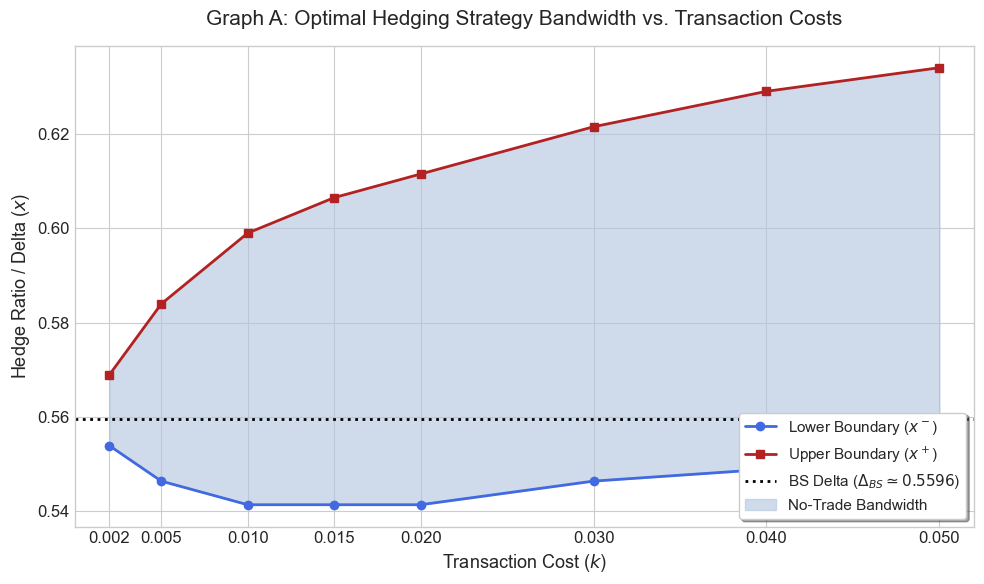

In [16]:
# Part (c): Plotting Graph A Re-creation
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the extracted boundaries
ax.plot(k_values, boundaries[:, 0], marker='o', linestyle='-', linewidth=2, color='royalblue', label=r'Lower Boundary ($x^-$)')
ax.plot(k_values, boundaries[:, 1], marker='s', linestyle='-', linewidth=2, color='firebrick', label=r'Upper Boundary ($x^+$)')

# Plot the frictionless reference line (Fixed the raw f-string warning here with 'rf')
ax.axhline(bs_delta, color='black', linestyle=':', linewidth=2, label=rf'BS Delta ($\Delta_{{BS}} \simeq {bs_delta:.4f}$)')

# Shade the expanding no-trade region
ax.fill_between(k_values, boundaries[:, 0], boundaries[:, 1], color='lightsteelblue', alpha=0.6, label='No-Trade Bandwidth')

# Annotations & Styling
ax.set_title("Graph A: Optimal Hedging Strategy Bandwidth vs. Transaction Costs", fontsize=15, pad=15)
ax.set_xlabel("Transaction Cost ($k$)", fontsize=13)
ax.set_ylabel("Hedge Ratio / Delta ($x$)", fontsize=13)
ax.set_xticks(k_values)
ax.set_xlim(0, max(k_values) + 0.002)
ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)

plt.tight_layout()
plt.show()